# Instructions

**Please follow these instructions carefully to ensure your submission is graded correctly:**

- Fill in **your answers** in any place that says "YOUR CODE HERE" or "YOUR ANSWER HERE" in the provided `.ipynb` files.

- Do not use print statements or the variable name `_` to display your answers; instead, make sure the last line of the cell contains the variable that holds your answer.

- Your answers to code-based questions must be **generated from code**. Hardcoded answers will result in a deduction of points.  

- Do not change the **autograding cells** labelled with `"AUTOGRADING CELL - DO NOT TOUCH!"`. Modifying or deleting them may lead to incorrect grading results.

- All plots must have appropriate **axis labels** including units where applicable. Failing to do so will result in a partial deduction of points.

- Always proide **units** for quantities where applicable. Failing to do so will result in a partial deduction of points.

- The **code quality** will not be graded. However, concise, well-structured code makes it easier to awared partial points in case of errors.

- The quality of **written answers** and **figures** will be considered during grading.

- Do not use additional packages that are not part of the course **environment**. This would lead to errors during autograding.

- Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

- Submissions must be your own work, **plagiarism** from the web or peers will be checked for and sanctioned.

- Please upload only the provided `.ipynb` files, filled in with your answers.

- Please **do not** put the `.ipynb` files into archives (e.g., `.zip`, `.tar.gz`); also `.py` files will **not** be accepted. Please **do not change the file names** and do not upload additional files.

- Submission on ISIS *(for TU Berlin students)* requires **two-factor authentication**.

---

## Task 3: Run-of-River Plant (31 points)

You have been tasked with designing a small run-of-river power plant near Cullen in Northern Scotland with a catchment area of 46.5 km² shown below.

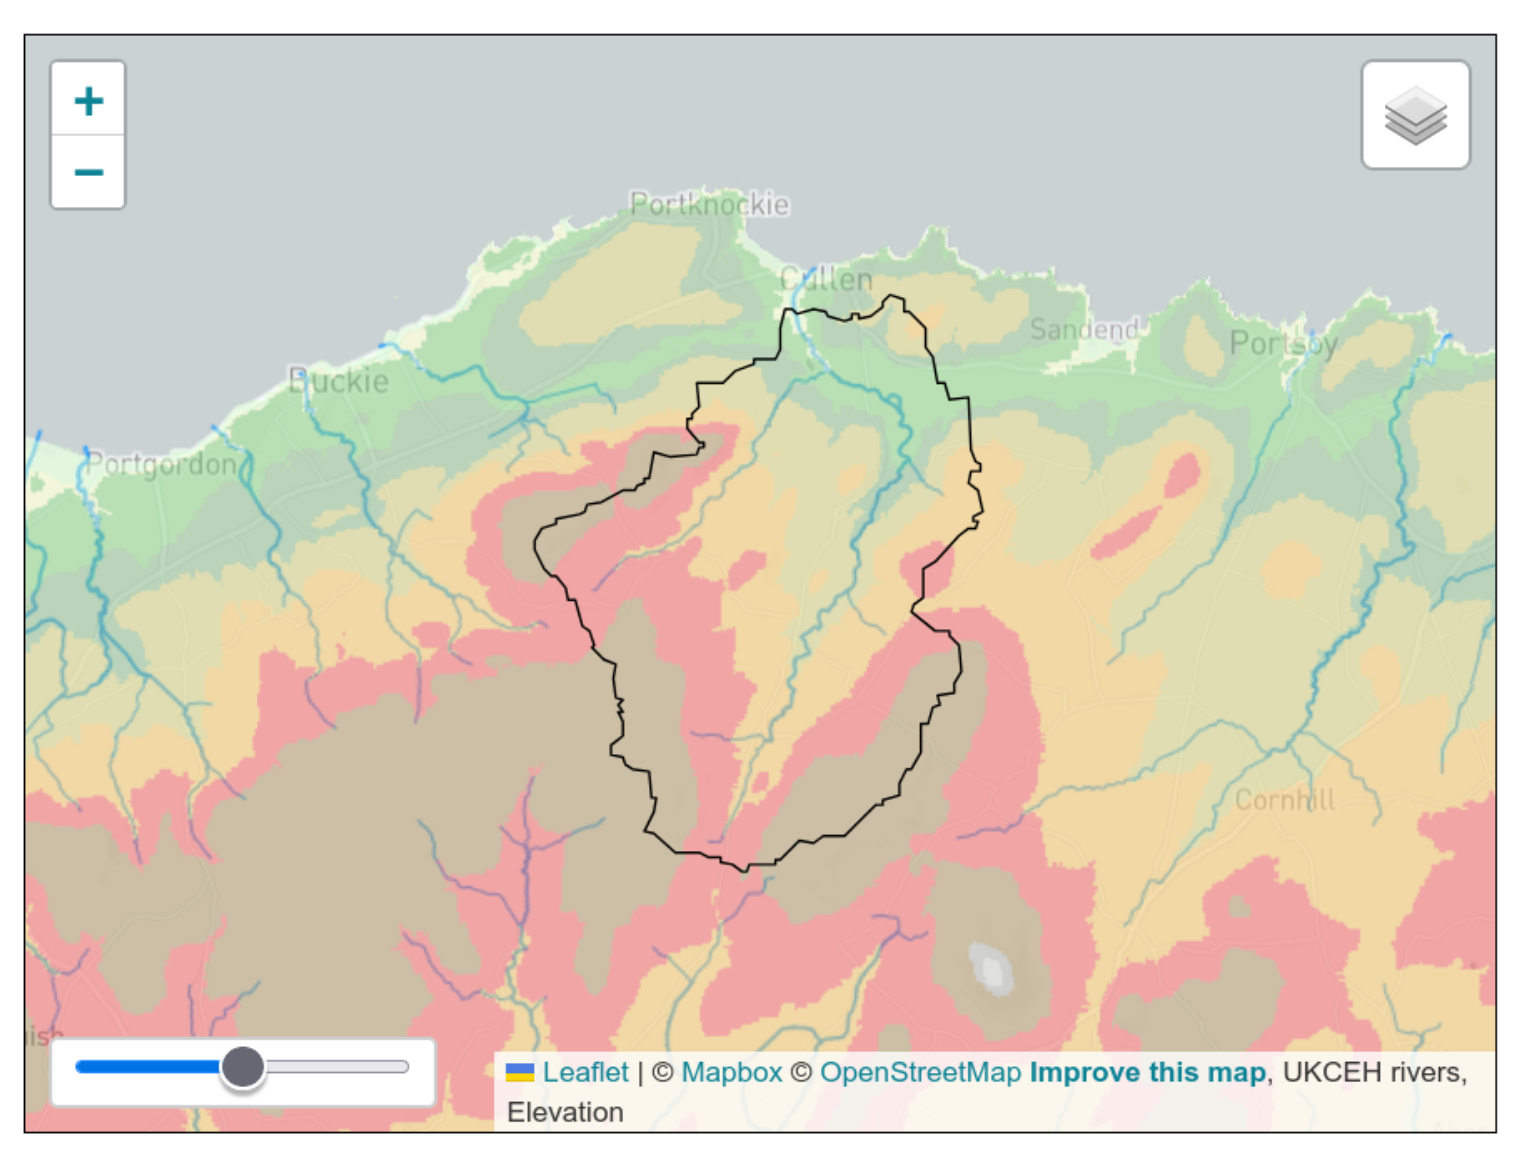

For the evaluation of the site, you have been given a daily time series of measured daily water flow rates (in m³/s) for multiple decades sourced from the [UK National River Flow Archive](https://nrfa.ceh.ac.uk/data/station/info/9006):

In [1]:
url = "https://tubcloud.tu-berlin.de/s/EgeJmPWPferX6QR/download/9006_gdf.csv"

The project lead has also already identified a suitable location for the weir, which would result in a net head of 100 metres. For the following calculations, assume a generator efficiency of 90% and that the weir cannot store significant amounts of water inflow across days.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**a)** Read the provided dataset as a `pandas.Series` so that the index is a `pandas.DatetimeIndex`. Make sure to skip the initial rows with metadata and forward fill any missing values. Return the resulting `pandas.Series`. **(4 points)**


In [3]:
# YOUR CODE HERE
# series = pd.read_csv(url, index_col=0, skiprows = 19)
# series
df = pd.read_csv(url, index_col = 0,skiprows = 19, parse_dates=True)
series = df.iloc[:, 0]
series_filled = series.ffill()
series_filled

data
1989-12-01    0.138
1989-12-02    0.137
1989-12-03    0.133
1989-12-04    0.130
1989-12-05    0.128
              ...  
2023-09-26    0.187
2023-09-27    0.236
2023-09-28    0.305
2023-09-29    0.215
2023-09-30    0.179
Name: last, Length: 12357, dtype: float64

In [4]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

In [5]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [6]:
### AUTOGRADING CELL - DO NOT TOUCH!


**b)** Resample the series to a monthly frequency by taking the mean of each month. Plot the resulting time series on a `matplotlib` figure of size 18 by 4 inches and apply appropriate labels. **(2 points)**


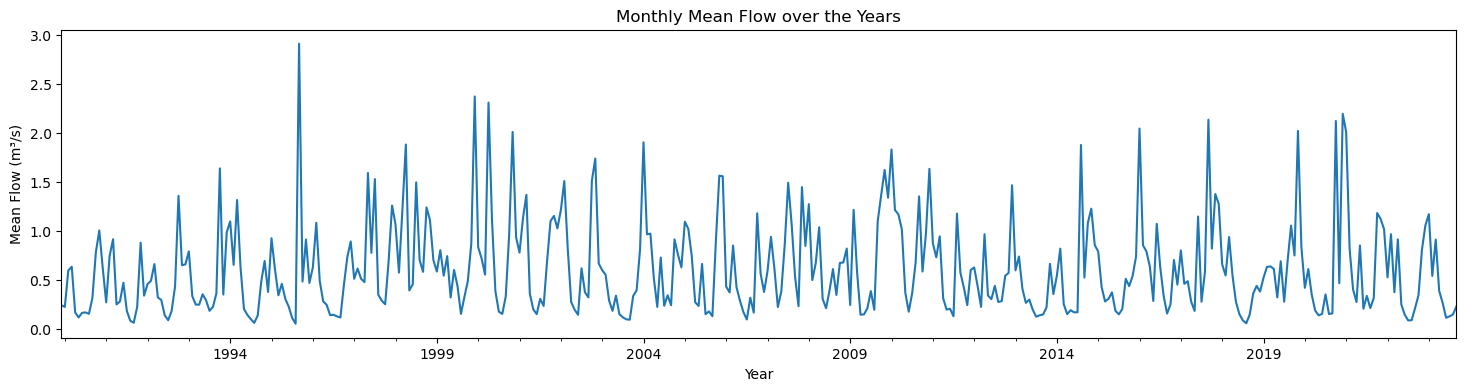

In [7]:
# YOUR CODE HERE
series_filled.resample('ME').mean().plot(figsize=(18, 4))
plt.xlabel('Year')
plt.ylabel('Mean Flow (m³/s)')
plt.title('Monthly Mean Flow over the Years')
plt.show()


Not all of the water the river carries can be used to produce power. A compensation flow must remain in the river at all times when available from the upstream catchment. For the compensation flow assume the 8% quantile of flows (i.e. flow rate exceeded 92% of the time). Economically, it often does not make sense to dimension the penstock and generator for the peak flow rate. Initially, assume a rated flow (i.e. the maximum flow the penstock and generator can handle) corresponding to the 75% quantile (i.e. flow rate exceeded 25% of the time). Assume that any flow above the rated flow is spilled without producing power, and that the turbine can operate at partial load down to the compensation flow.

**c)** What is the value for the compensation flow in m³/s? Return the result as a float. **(1 point)**


In [8]:
# YOUR CODE HERE
compensation_flow = series_filled.quantile(0.08)
compensation_flow

np.float64(0.114)

In [9]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)


**d)** What is the value for the rated flow in m³/s? Return the result as a float. **(1 point)**


In [10]:
# YOUR CODE HERE
rated_flow = series_filled.quantile(0.75)
rated_flow

np.float64(0.652)

In [11]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)


**e)** Calculate a time series at daily resolution for the available flow for power production after accounting for the compensation flow and rated flow. Return the result as a `pandas.Series`. **(4 points)**


In [12]:
# YOUR CODE HERE
# rated_flow or less, also subtract the compensation flow from each
available_flow = (series_filled - compensation_flow).clip(lower=0, upper=rated_flow)
available_flow

data
1989-12-01    0.024
1989-12-02    0.023
1989-12-03    0.019
1989-12-04    0.016
1989-12-05    0.014
              ...  
2023-09-26    0.073
2023-09-27    0.122
2023-09-28    0.191
2023-09-29    0.101
2023-09-30    0.065
Name: last, Length: 12357, dtype: float64

In [13]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

In [14]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [15]:
### AUTOGRADING CELL - DO NOT TOUCH!

In [16]:
### AUTOGRADING CELL - DO NOT TOUCH!


**f)** In one figure, plot a duration curve for the total flow in the river and the available flow for power production. The x-axis should indicate the percentage of time the flow is exceeded. Limit the y-axis to 3 m³/s. Label the figure appropriately. **(2 points)**


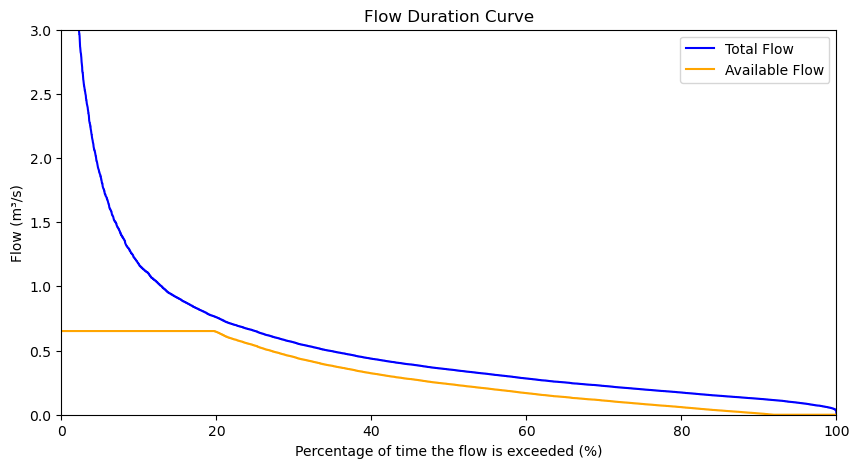

In [17]:
# YOUR CODE HERE

n = len(series_filled)
exceedance_pct = np.arange(1, n + 1) / n * 100
total_flow_sorted = series_filled.sort_values(ascending=False).values
available_flow_sorted = available_flow.sort_values(ascending=False).values

plt.figure(figsize=(10, 5))
plt.plot(exceedance_pct, total_flow_sorted, label='Total Flow', color='blue')
plt.plot(exceedance_pct, available_flow_sorted, label='Available Flow', color='orange')
plt.ylim(0, 3)  
plt.xlim(0, 100) 

plt.xlabel('Percentage of time the flow is exceeded (%)')
plt.ylabel('Flow (m³/s)')
plt.title('Flow Duration Curve')
plt.legend()


**g)** Determine the rated power of the run-of-river plant (in kW) using the rated flow. Return the result as a float. **(2 points)**


In [18]:
# YOUR CODE HERE
efficiency = 0.90
density_water = 1000  # in kg/m^3
gravity = 9.81        # in m/s^2
net_head = 100        # in meters

rated_power_watts = efficiency * density_water * gravity * rated_flow * net_head
rated_power_kw = float(rated_power_watts / 1000)
rated_power_kw

575.6507999999999

In [19]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

In [20]:
### AUTOGRADING CELL - DO NOT TOUCH!


**h)** Compute a time series for the daily electricity production (in kWh) of the run-of-river plant based on the available flow. Return the result as a `pandas.Series`. **(2 points)**


In [21]:
# YOUR CODE HERE
available_flow_series = ((available_flow * efficiency * density_water * gravity * net_head) / 1000) * 24
available_flow_series

data
1989-12-01     508.5504
1989-12-02     487.3608
1989-12-03     402.6024
1989-12-04     339.0336
1989-12-05     296.6544
                ...    
2023-09-26    1546.8408
2023-09-27    2585.1312
2023-09-28    4047.2136
2023-09-29    2140.1496
2023-09-30    1377.3240
Name: last, Length: 12357, dtype: float64

In [22]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

In [23]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)


**i)** What is the long-term average capacity factor of the run-of-river plant? Return the result as a float between 0 and 1. **(2 points)**


In [24]:
# YOUR CODE HERE

total_days = len(available_flow_series)
max_total_energy = rated_power_kw * 24 * total_days
capacity_factor = float(available_flow_series.sum() / max_total_energy)
capacity_factor


0.45436033623424993

In [25]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)
assert 0 <= _ <= 1


**j)** Compute the annual energy yield anomalies of the plant (in MWh) for each calendar year relative to the long-term mean annual yield. Plot the anomalies in a bar chart with a horizontal line at zero and appropriate axis labels. **(2 points)**


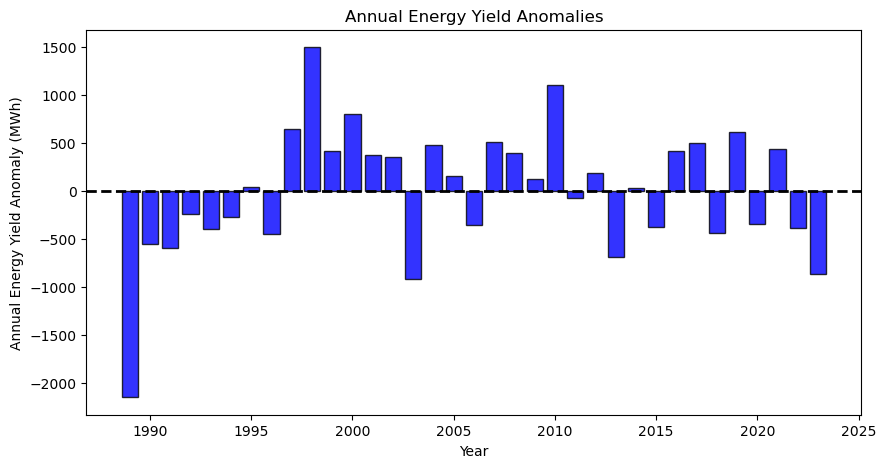

In [26]:
# YOUR CODE HERE
available_flow_mwh = available_flow_series/1000
annual_yield = available_flow_mwh.resample('YE').sum()
mean_annual_yield = annual_yield.mean()
anomalies = annual_yield - mean_annual_yield

plt.figure(figsize=(10, 5))
plt.bar(anomalies.index.year, anomalies.values, color='blue', edgecolor='black', alpha=0.8)
plt.axhline(0, color='black', linewidth=2, linestyle='--')
plt.xlabel('Year')
plt.ylabel('Annual Energy Yield Anomaly (MWh)')
plt.title('Annual Energy Yield Anomalies')
plt.show()



**k)** Compute and plot the relationship between power rating (x-axis) and average annual energy yield (y-axis) by iterating through rated flows between the 5% and 95% quantiles of flow in increments of 5%. **(4 points)**


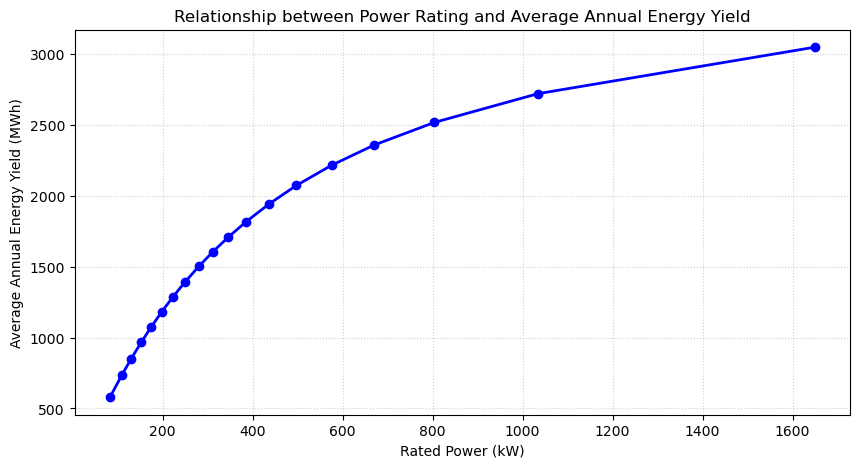

In [27]:
# YOUR CODE HERE

power_ratings_kw = []
avg_annual_yields_mwh = []

for i in range(5, 100, 5):
    current_rated_flow = series_filled.quantile(i / 100)
    current_power_kw = float((efficiency * density_water * gravity * current_rated_flow * net_head) / 1000)
    power_ratings_kw.append(current_power_kw)
    current_available_flow = series_filled - compensation_flow
    current_available_flow = current_available_flow.clip(lower=0, upper=current_rated_flow)
    daily_energy_mwh = ((current_available_flow * efficiency * density_water * gravity * net_head) / 1000) * 24 / 1000
    mean_annual_yield = float(daily_energy_mwh.resample('YE').sum().mean())
    avg_annual_yields_mwh.append(mean_annual_yield)

plt.figure(figsize=(10, 5))
plt.plot(power_ratings_kw, avg_annual_yields_mwh, marker='o', color='blue', linestyle='-', linewidth=2)
plt.xlabel('Rated Power (kW)')
plt.ylabel('Average Annual Energy Yield (MWh)')
plt.title('Relationship between Power Rating and Average Annual Energy Yield')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()




**l)** Based on the plot in **k)**, explain why it might make sense to limit the design flow and what the slope of the curve indicates. **(2 points)**


Based on the plot in k, it makes sense to limit the design flow because the curve demonstrates diminishing returns. Initially the slope is rapidly increased as rated power increases, so there are increasing marginal returns to expanding the rated power of the plant. However, once about 800 kW of rate power is reached, the returns to the average annual energy yield marginally slow down a significant amount. This makes it less beneficial to continue to design for a plant with a very high rated power. There should be a cap on the rated power at some point where the diminishing returns to increasing rated power are too great to justify spending the money on more design improvements.

**m)** Compute the relative increase in average annual energy yield (in %) when dropping the consideration of the compensation flow. Return the result as a float. **(3 points)**

In [28]:
# YOUR CODE HERE
# series_filled -> resample to each month 
# rated_flow (max flow the system can handle) 

original_rated_flow = series_filled.quantile(0.75)
original_available = (series_filled - compensation_flow).clip(lower=0, upper=original_rated_flow)
original_daily_mwh = ((original_available * efficiency * density_water * gravity * net_head) / 1000) * 24 / 1000
original_mean_annual_yield = original_daily_mwh.resample("YE").sum().mean()
new_available_flow = series_filled.clip(lower=0, upper=original_rated_flow)
new_daily_mwh = ((new_available_flow * efficiency * density_water * gravity * net_head) / 1000) * 24 / 1000
new_mean_annual_yield = new_daily_mwh.resample("YE").sum().mean()
relative_increase_pct = float(((new_mean_annual_yield - original_mean_annual_yield) / original_mean_annual_yield) * 100)
relative_increase_pct

29.147501252501602

In [29]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

In [30]:
### AUTOGRADING CELL - DO NOT TOUCH!